### Hidden Markov Model

In [47]:
import numpy as np
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from hmmlearn import hmm

In [55]:
# Set a random seed for reproducibility
np.random.seed(42)

# Define the simulation parameters
n_days = 365 # simulate one year
start_date = datetime(2024, 1, 1)

In [56]:
# Define hidden states (0: Cold, 1: Moderate, 2: Warm)
states = [0, 1, 2]
n_states = len(states)

# Define transition probability matrix for the hidden Markov chain
transition_matrix = np.array([
    [0.80, 0.15, 0.05],  # from Cold, mostly stay Cold, sometimes go to Moderate
    [0.10, 0.80, 0.10],  # from Moderate, can transition to either Cold or Warm
    [0.05, 0.15, 0.80]   # from Warm, mostly stay Warm, sometimes to Moderate
])

In [57]:
# Define the means and standard deviations for temperature and humidity for each state
# For example:
# - Cold: lower temperature, higher humidity (as colder air holds less moisture, you can tweak these values)
# - Moderate: moderate temperature and humidity
# - Warm: higher temperature, lower humidity
state_params = {
    0: {'temp_mean': 30, 'temp_std': 5, 'hum_mean': 80, 'hum_std': 5},
    1: {'temp_mean': 60, 'temp_std': 5, 'hum_mean': 60, 'hum_std': 5},
    2: {'temp_mean': 90, 'temp_std': 5, 'hum_mean': 40, 'hum_std': 5},
}

In [58]:
# Simulate hidden states over time using the transition matrix
hidden_states = [np.random.choice(states, p=[1/n_states]*n_states)]  # random initial state
for _ in range(1, n_days):
    current_state = hidden_states[-1]
    next_state = np.random.choice(states, p=transition_matrix[current_state])
    hidden_states.append(next_state)
hidden_states = np.array(hidden_states)

In [59]:
# Simulate observations (temperature and humidity) based on the current state
temperatures = []
humidities = []
for state in hidden_states:
    params = state_params[state]
    temp = np.random.normal(params['temp_mean'], params['temp_std'])
    hum = np.random.normal(params['hum_mean'], params['hum_std'])
    temperatures.append(temp)
    humidities.append(hum)
temperatures = np.array(temperatures)
humidities = np.array(humidities)

In [60]:
# Create a date range for the dataset
dates = [start_date + timedelta(days=i) for i in range(n_days)]

In [61]:
# Create a DataFrame to store the synthetic data
data = pd.DataFrame({
    'Date': dates,
    'Temperature': temperatures,
    'Humidity': humidities,
    'True_State': hidden_states
})

In [62]:
# Display the first few rows of the dataset
print("Sample of the simulated dataset:")
print(data.head())

Sample of the simulated dataset:
        Date  Temperature   Humidity  True_State
0 2024-01-01    62.196636  59.457511           1
1 2024-01-02    87.567836  41.037991           2
2 2024-01-03    94.424952  37.677351           2
3 2024-01-04    86.888814  38.222557           2
4 2024-01-05    64.760055  67.262751           1


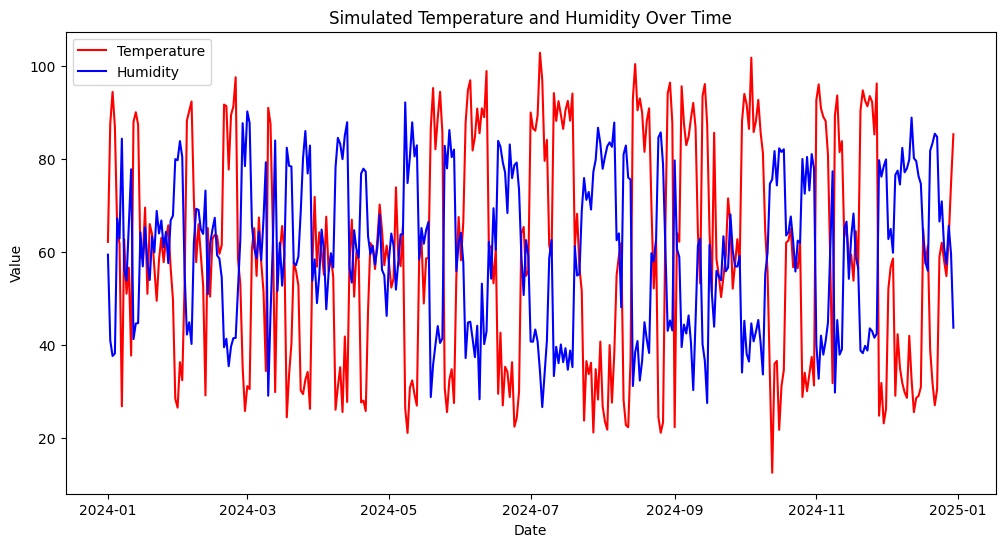

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(dates, temperatures, label='Temperature', color='red')
plt.plot(dates, humidities, label='Humidity', color='blue')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Simulated Temperature and Humidity Over Time')
plt.legend()
plt.show()

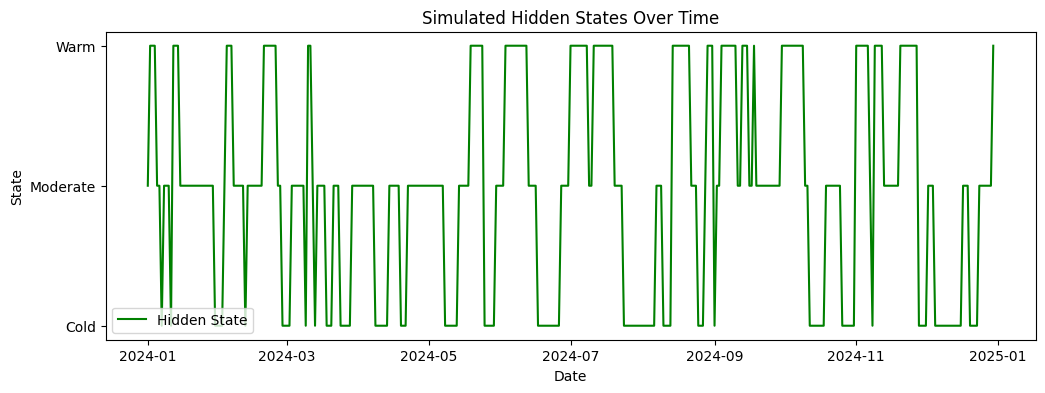

In [69]:
plt.figure(figsize=(12, 4))
plt.plot(dates, hidden_states, label='Hidden State', color='green')
plt.xlabel('Date')
plt.ylabel('State')
plt.title('Simulated Hidden States Over Time')
plt.yticks(states, ['Cold', 'Moderate', 'Warm'])
plt.legend()
plt.show()

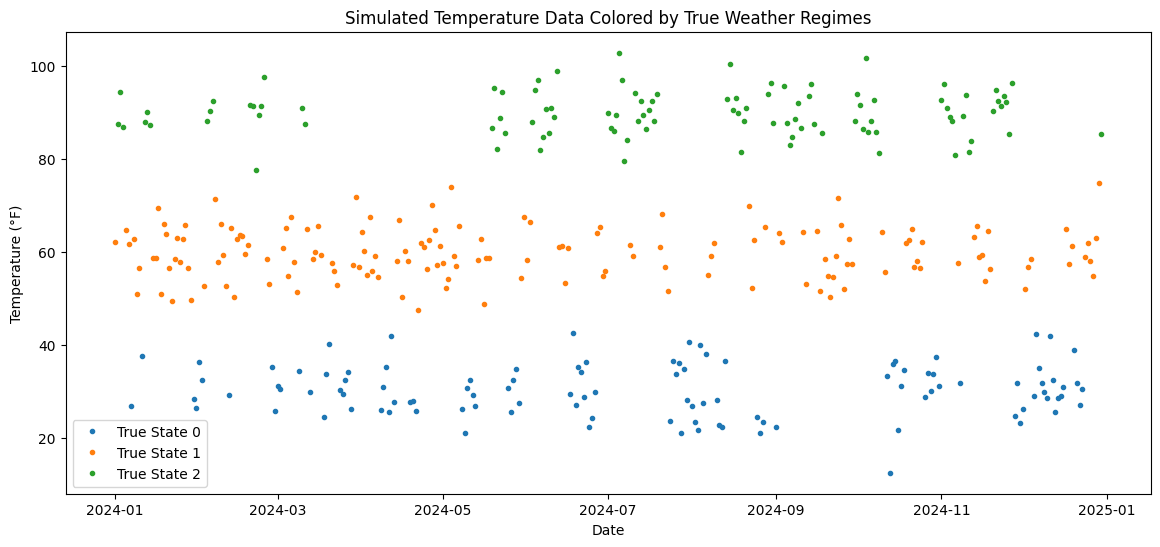

In [64]:
# Plot the temperature over time colored by the true hidden state
plt.figure(figsize=(14, 6))
for state in states:
    state_data = data[data['True_State'] == state]
    plt.plot(state_data['Date'], state_data['Temperature'], '.', label=f'True State {state}')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.title('Simulated Temperature Data Colored by True Weather Regimes')
plt.legend()
plt.show()

In [65]:
# Save the dataset to a CSV file
data.to_csv('synthetic_weather_data.csv', index=False)
print("Dataset saved to 'synthetic_weather_data.csv'")

Dataset saved to 'synthetic_weather_data.csv'


In [66]:
# Prepare the observations for the HMM (we use both Temperature and Humidity)
# hmmlearn expects a 2D array: (n_samples, n_features)
observations = data[['Temperature', 'Humidity']].values

# Initialize the Gaussian HMM with 3 states
model = hmm.GaussianHMM(n_components=n_states, covariance_type='diag', n_iter=1000, random_state=42)

# Fit the model to the observations
model.fit(observations)

# Predict the hidden states using the trained model
predicted_states = model.predict(observations)

# Add the predicted states to the DataFrame
data['Predicted_State'] = predicted_states

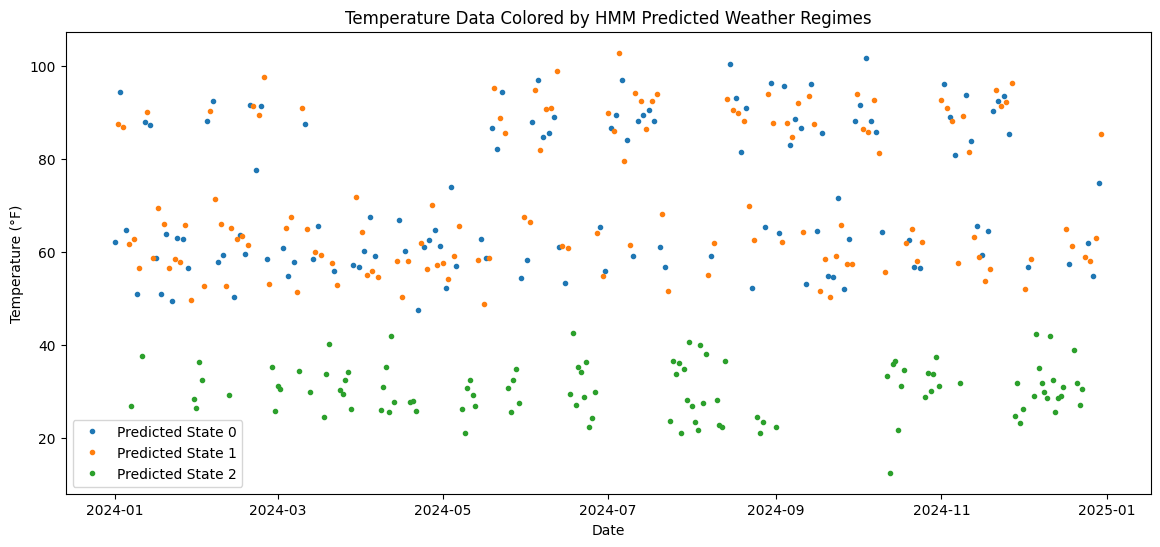

In [67]:
plt.figure(figsize=(14, 6))
for state in range(n_states):
    state_data = data[data['Predicted_State'] == state]
    plt.plot(state_data['Date'], state_data['Temperature'], '.', label=f'Predicted State {state}')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.title('Temperature Data Colored by HMM Predicted Weather Regimes')
plt.legend()
plt.show()


In [68]:
# Compare the true states with the predicted states by printing a confusion table
confusion_table = pd.crosstab(data['True_State'], data['Predicted_State'], rownames=['True'], colnames=['Predicted'])
print("\nConfusion Table between True States and Predicted States:")
print(confusion_table)

# Print learned model parameters
print("\nLearned Transition Matrix:")
print(model.transmat_)

print("\nLearned Means (for Temperature and Humidity in each state):")
print(model.means_)

print("\nLearned Covariances (diagonal covariances for each state):")
print(model.covars_)


Confusion Table between True States and Predicted States:
Predicted   0   1    2
True                  
0           0   0  107
1          71  86    0
2          50  51    0

Learned Transition Matrix:
[[0.00533383 0.99350744 0.00115873]
 [0.79479914 0.03501963 0.17018123]
 [0.05531495 0.16799106 0.77669398]]

Learned Means (for Temperature and Humidity in each state):
[[72.12153014 51.74254051]
 [71.04002246 52.68310308]
 [30.32830887 80.09022424]]

Learned Covariances (diagonal covariances for each state):
[[[241.33228631   0.        ]
  [  0.         128.56973795]]

 [[244.82186192   0.        ]
  [  0.         121.38564498]]

 [[ 30.40658193   0.        ]
  [  0.          20.58368969]]]
